# Task 2: Exploratory Data Analysis — Titanic Dataset

This notebook is written as a guided EDA: each section explains why a step is useful before running the code.

## 1. Objective

The objective is to understand the Titanic dataset using descriptive statistics and visualizations, identify patterns, relationships, anomalies, and potential data-quality issues. Findings describe associations in this dataset; they do not establish causation.

## 2. Dataset Overview

Each row represents a passenger. `Survived` is the outcome (0 = no, 1 = yes); `Pclass` is ticket class (1 is highest); `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Cabin`, and `Embarked` describe passenger characteristics and travel details.

## 3. Import Libraries

Pandas manages tabular data, NumPy supports numeric work, Matplotlib/Seaborn create static charts, and Plotly adds one interactive view.

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', None)


In [4]:
!pip install plotly
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 3.4 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [statsmodels] [statsmodels]


## 4. Load the Dataset

The relative path keeps the notebook portable when it is run from the `notebooks` directory.

In [6]:
DATA_PATH = Path('../data/titanic.csv')
df_raw = pd.read_csv(DATA_PATH)
df_raw.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 5. Initial Data Inspection

First, inspect dimensions, column names, types, sample rows, missingness, and duplicate records. This tells us what must be addressed before analysis or modelling.

In [7]:
print('Shape:', df_raw.shape)
print('\nColumns:', df_raw.columns.tolist())
print('\nData types:')
display(df_raw.dtypes)
display(df_raw.head())
display(df_raw.tail())
df_raw.info()
print('\nMissing values:')
display(df_raw.isna().sum().sort_values(ascending=False).to_frame('missing'))
print('Duplicate rows:', df_raw.duplicated().sum())

Shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data types:


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Missing values:


,missing
Cabin,687
Age,177
Embarked,2
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
SibSp,0
Parch,0


Duplicate rows: 0


## 6. Data Cleaning

We retain `df_raw` unchanged and make an analysis copy. `Age` is median-imputed because its distribution is not perfectly symmetric and the median is robust to extreme values. `Embarked` has only two missing records, so mode imputation is reasonable. `Cabin` is mostly missing; rather than invent cabin values, we create a transparent `HasCabin` indicator and drop the high-missingness text field from the numeric analysis. Duplicate rows are checked but not removed unless present.

In [8]:
df = df_raw.copy()
missing_before = df.isna().sum()
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['HasCabin'] = df['Cabin'].notna().astype(int)
df = df.drop(columns='Cabin')
df = df.drop_duplicates()
display(pd.DataFrame({'before': missing_before, 'after': df.reindex(columns=df_raw.columns, fill_value=np.nan).isna().sum()}))
print('Analysis-copy shape after cleaning:', df.shape)

,before,after
PassengerId,0,0
Survived,0,0
Pclass,0,0
Name,0,0
Sex,0,0
Age,177,0
SibSp,0,0
Parch,0,0
Ticket,0,0
Fare,0,0


Analysis-copy shape after cleaning: (891, 12)


## 7. Descriptive Statistics

`describe()` supplies count, mean, standard deviation, minimum, quartiles, and maximum. Median is added explicitly because comparing it with the mean helps reveal skew.

In [9]:
numeric = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'Survived']
stats = df[numeric].describe().T
stats['median'] = df[numeric].median()
display(stats[['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max']])
for col in ['Age', 'Fare']:
    print(f'{col}: mean = {df[col].mean():.2f}, median = {df[col].median():.2f}')
print('A mean much larger than the median, as for Fare, suggests a right tail.')

,count,mean,median,std,min,25%,50%,75%,max
Age,891.0,29.361582,28.0000,13.019697,0.42,22.0000,28.0000,35.0,80.0000
Fare,891.0,32.204208,14.4542,49.693429,0.00,7.9104,14.4542,31.0,512.3292
SibSp,891.0,0.523008,0.0000,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.0000,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Pclass,891.0,2.308642,3.0000,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Survived,891.0,0.383838,0.0000,0.486592,0.00,0.0000,0.0000,1.0,1.0000


Age: mean = 29.36, median = 28.00
Fare: mean = 32.20, median = 14.45
A mean much larger than the median, as for Fare, suggests a right tail.


## 8. Univariate Analysis

Univariate charts show the distribution of one variable at a time. They make shape, imbalance, and unusual values easier to see.

### 8.1 Age Distribution

A histogram with KDE shows where passenger ages concentrate after the documented median imputation.

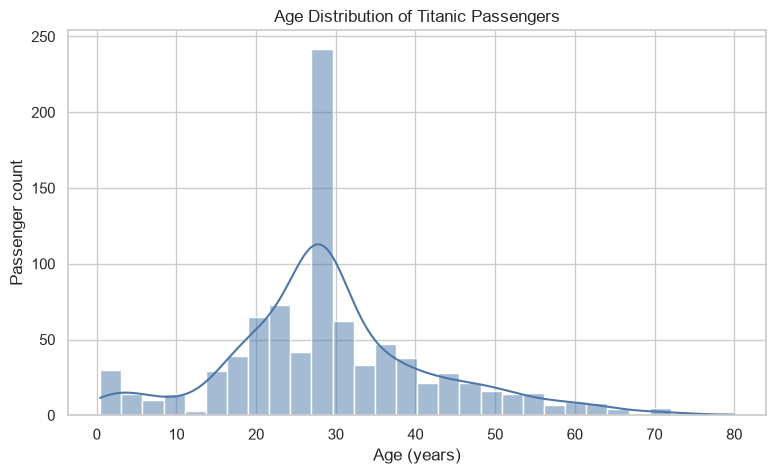

In [10]:
plt.figure(figsize=(9, 5))
sns.histplot(df['Age'], bins=30, kde=True, color='#4C78A8')
plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age (years)'); plt.ylabel('Passenger count')
plt.show()

### 8.2 Fare Distribution

The histogram and boxplot show both the overall shape and values far from the central range.

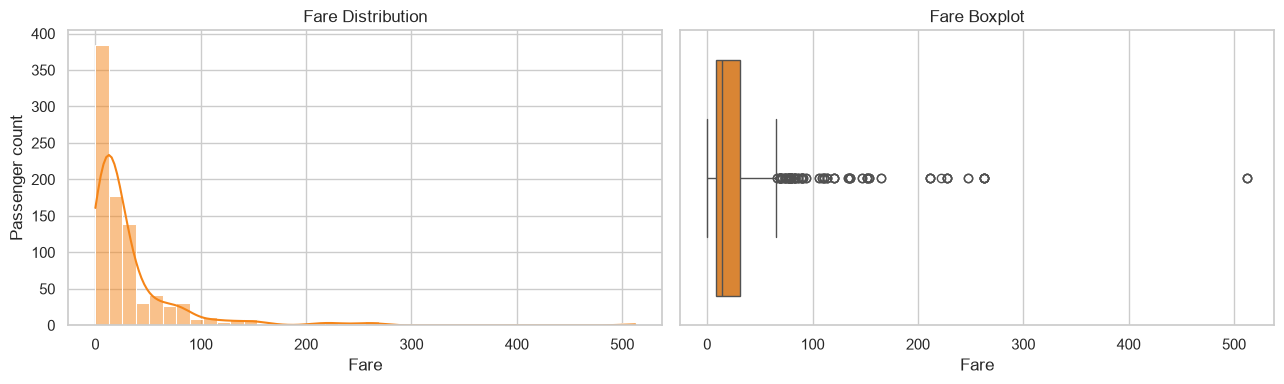

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df['Fare'], bins=40, kde=True, ax=axes[0], color='#F58518')
axes[0].set(title='Fare Distribution', xlabel='Fare', ylabel='Passenger count')
sns.boxplot(x=df['Fare'], ax=axes[1], color='#F58518')
axes[1].set(title='Fare Boxplot', xlabel='Fare')
plt.tight_layout(); plt.show()

### 8.3 Passenger Class Distribution

This countplot shows how many records belong to each ticket class.

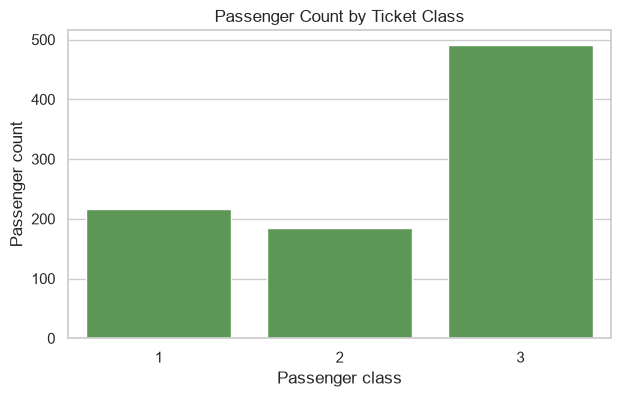

In [12]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Pclass', order=[1, 2, 3], color='#54A24B')
plt.title('Passenger Count by Ticket Class'); plt.xlabel('Passenger class'); plt.ylabel('Passenger count')
plt.show()

### 8.4 Survival Distribution

Counts and percentages expose the class balance of the target variable.

,percentage
Survived,
Did not survive,61.616162
Survived,38.383838


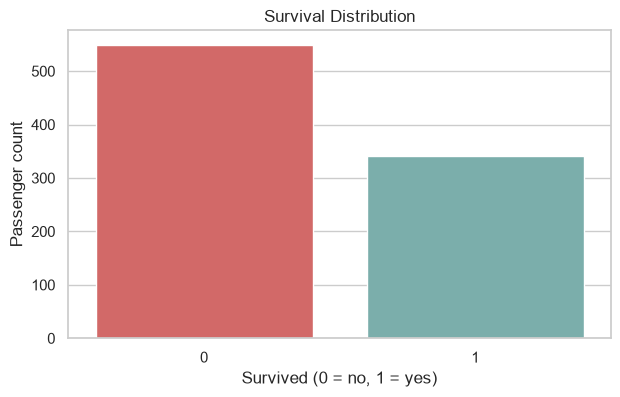

In [13]:
survival_pct = df['Survived'].value_counts(normalize=True).sort_index().mul(100)
display(survival_pct.rename(index={0: 'Did not survive', 1: 'Survived'}).to_frame('percentage'))
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Survived', hue='Survived', legend=False, palette=['#E45756', '#72B7B2'])
plt.title('Survival Distribution'); plt.xlabel('Survived (0 = no, 1 = yes)'); plt.ylabel('Passenger count')
plt.show()

Plotly is useful here because its interactive bars let a reader inspect exact survival percentages in a live notebook.

In [14]:
survival_plot = survival_pct.rename(index={0: 'Did not survive', 1: 'Survived'}).reset_index()
survival_plot.columns = ['Outcome', 'Percentage']
fig = px.bar(survival_plot, x='Outcome', y='Percentage', text='Percentage', color='Outcome', title='Interactive Survival Percentage')
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(yaxis_title='Percentage of passengers', showlegend=False)
fig.show()

## 9. Bivariate Analysis

These views compare two variables. They describe observed relationships, not causes.

### 9.1 Survival vs Gender

Compare survival counts and calculate group-level survival rates by sex.

,survival_rate_percent
Sex,
female,74.203822
male,18.890815


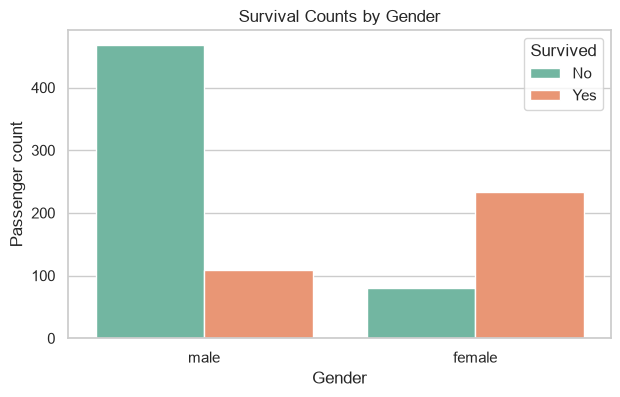

In [15]:
gender_rates = df.groupby('Sex')['Survived'].mean().sort_values(ascending=False).mul(100)
display(gender_rates.to_frame('survival_rate_percent'))
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Sex', hue='Survived', palette='Set2')
plt.title('Survival Counts by Gender'); plt.xlabel('Gender'); plt.ylabel('Passenger count'); plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

### 9.2 Survival vs Passenger Class

Calculate class-level rates alongside an easy-to-read bar chart.

,survival_rate_percent
Pclass,
1,62.962963
2,47.282609
3,24.236253


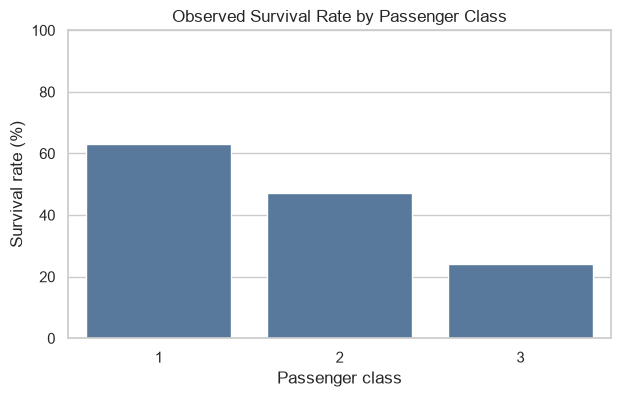

In [16]:
class_rates = df.groupby('Pclass')['Survived'].mean().mul(100)
display(class_rates.to_frame('survival_rate_percent'))
plt.figure(figsize=(7, 4))
sns.barplot(x=class_rates.index, y=class_rates.values, color='#4C78A8')
plt.title('Observed Survival Rate by Passenger Class'); plt.xlabel('Passenger class'); plt.ylabel('Survival rate (%)')
plt.ylim(0, 100); plt.show()

### 9.3 Age vs Survival

A boxplot compares the central spread of age for the two outcome groups.

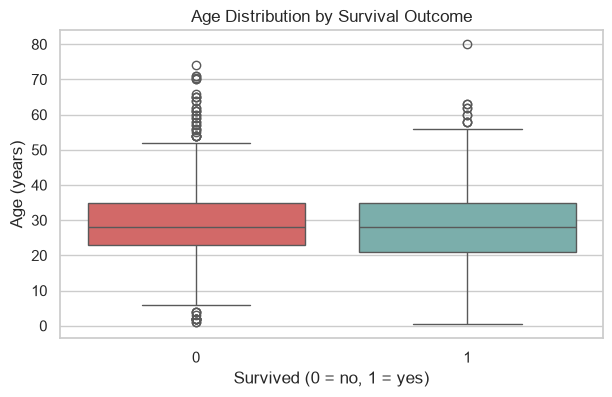

In [17]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Survived', y='Age', hue='Survived', legend=False, palette=['#E45756', '#72B7B2'])
plt.title('Age Distribution by Survival Outcome'); plt.xlabel('Survived (0 = no, 1 = yes)'); plt.ylabel('Age (years)')
plt.show()

### 9.4 Fare vs Survival

Fare is highly skewed, so this boxplot is interpreted with its long upper tail in mind.

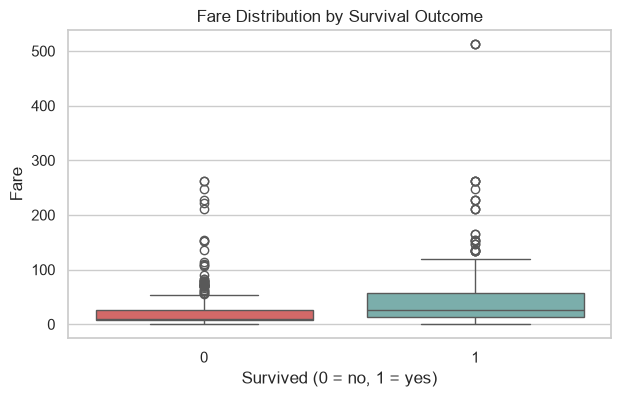

In [18]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Survived', y='Fare', hue='Survived', legend=False, palette=['#E45756', '#72B7B2'])
plt.title('Fare Distribution by Survival Outcome'); plt.xlabel('Survived (0 = no, 1 = yes)'); plt.ylabel('Fare')
plt.show()

## 10. Multivariate Analysis

Multivariate analysis examines several numeric features together. It can highlight co-movement and group separation, but it cannot prove one feature causes another.

### 10.1 Correlation Matrix

Correlation measures linear association from -1 to 1. A value near zero does not rule out nonlinear relationships; correlation does not imply causation.

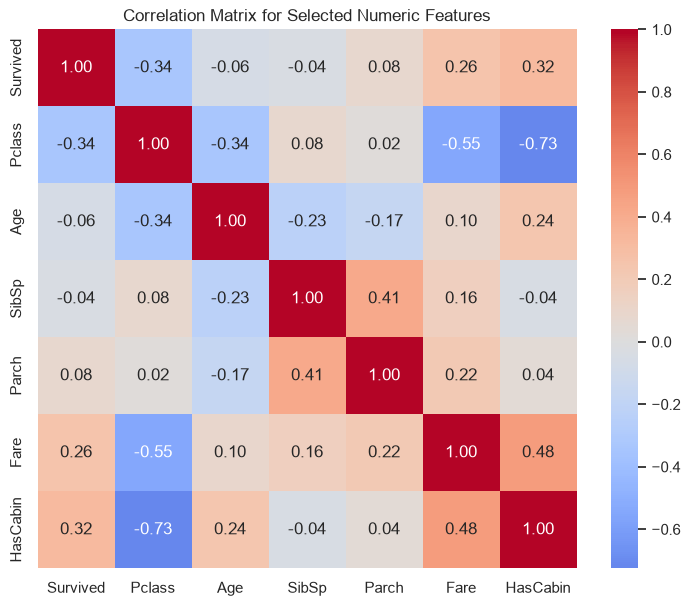

In [19]:
corr_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin']
corr = df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix for Selected Numeric Features')
plt.show()

### 10.2 Pairplot

A small subset keeps the plot readable. Colouring by survival helps spot possible group differences in the numeric distributions.

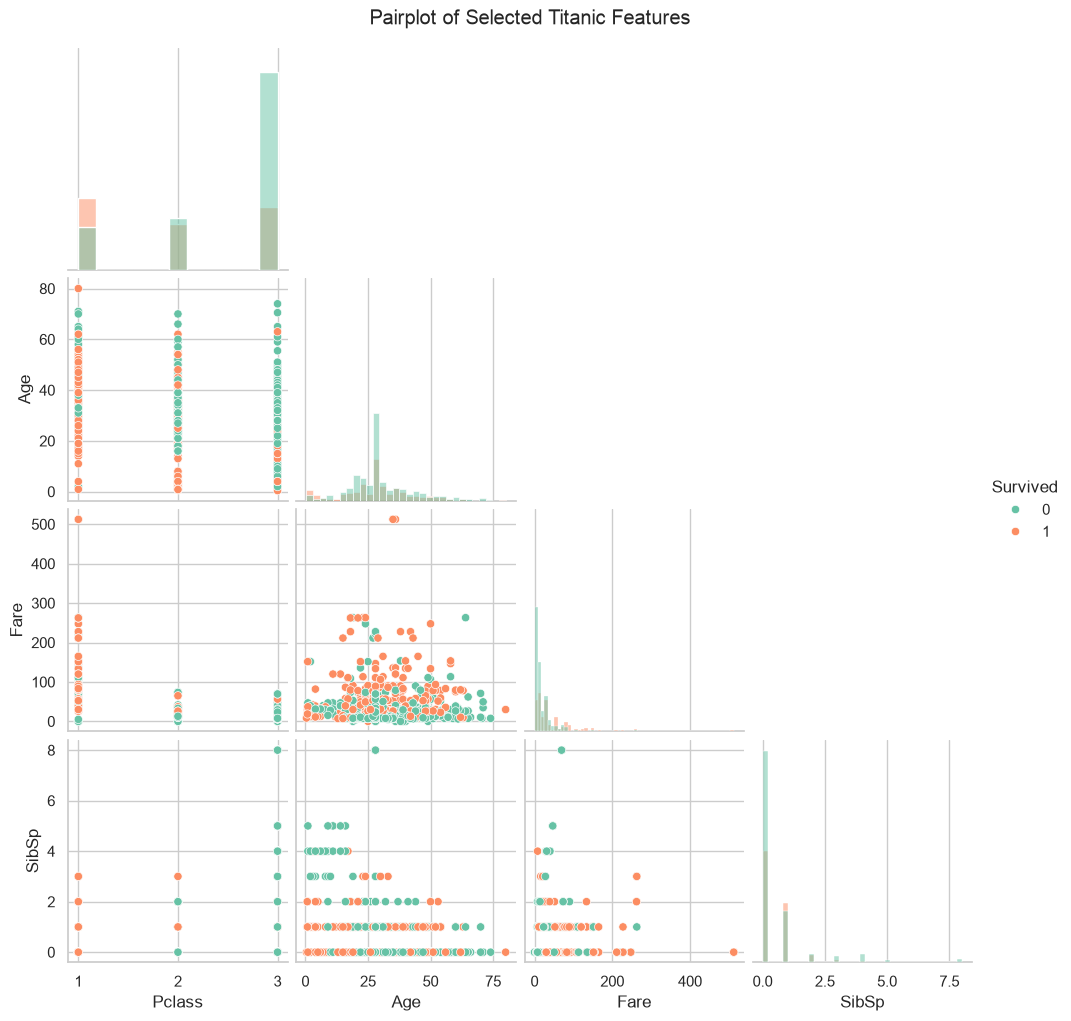

In [20]:
pair = sns.pairplot(df[['Survived', 'Pclass', 'Age', 'Fare', 'SibSp']], hue='Survived', corner=True, diag_kind='hist', palette='Set2')
pair.fig.suptitle('Pairplot of Selected Titanic Features', y=1.02)
plt.show()

## 11. Outlier Detection

The IQR rule flags values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR. A flagged value is a potential outlier, not automatically an error; no values are deleted here without a clear data-quality justification.

,feature,Q1,Q3,IQR,lower_bound,upper_bound,potential_outliers
0,Age,22.0000,35.0,13.0000,2.500,54.5000,66
1,Fare,7.9104,31.0,23.0896,-26.724,65.6344,116
2,SibSp,0.0000,1.0,1.0000,-1.500,2.5000,46
3,Parch,0.0000,0.0,0.0000,0.000,0.0000,213


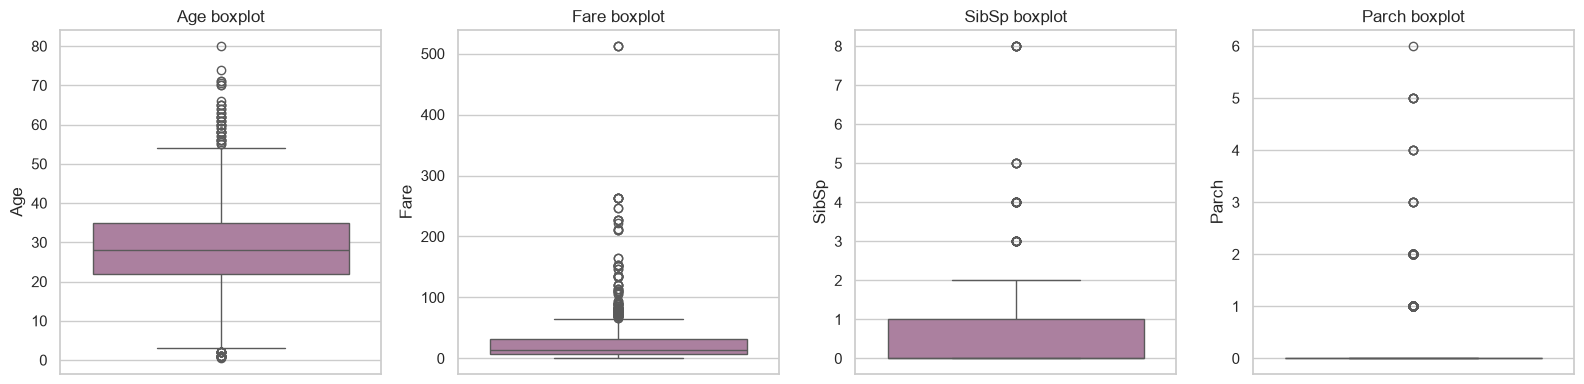

In [21]:
outlier_summary = []
for col in ['Age', 'Fare', 'SibSp', 'Parch']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    flagged = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append([col, q1, q3, iqr, lower, upper, flagged])
display(pd.DataFrame(outlier_summary, columns=['feature', 'Q1', 'Q3', 'IQR', 'lower_bound', 'upper_bound', 'potential_outliers']))
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ['Age', 'Fare', 'SibSp', 'Parch']):
    sns.boxplot(y=df[col], ax=ax, color='#B279A2')
    ax.set(title=f'{col} boxplot', ylabel=col)
plt.tight_layout(); plt.show()

## 12. Skewness Analysis

Skewness summarizes asymmetry: positive values indicate a longer right tail and negative values a longer left tail. Skewed variables can affect algorithms that use distance or assume roughly symmetric inputs; transformations may be considered later.

In [22]:
skewness = df[['Age', 'Fare', 'SibSp', 'Parch']].skew().sort_values(ascending=False)
display(skewness.to_frame('skewness'))
print('Fare is expected to be positively skewed when its mean exceeds its median and its upper tail is long.')

,skewness
Fare,4.787317
SibSp,3.695352
Parch,2.749117
Age,0.510245


Fare is expected to be positively skewed when its mean exceeds its median and its upper tail is long.


## 13. Multicollinearity Analysis

Multicollinearity means predictors carry overlapping linear information. It is especially important for coefficient-based statistical and linear models; tree-based models are generally less sensitive. Moderate correlation alone is not proof of problematic multicollinearity. VIF quantifies how much a predictor's variance is inflated by the others.

In [23]:
vif_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin']
X_vif = df[vif_features].astype(float).copy()
X_vif['intercept'] = 1.0
vif = pd.DataFrame({'feature': vif_features, 'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(vif_features))]})
display(vif.sort_values('VIF', ascending=False))
print('Review high VIF values in context; VIF is a diagnostic, not an automatic reason to discard a feature.')

,feature,VIF
0,Pclass,2.601735
5,HasCabin,2.160876
4,Fare,1.615068
2,SibSp,1.276167
3,Parch,1.265780
1,Age,1.201444


Review high VIF values in context; VIF is a diagnostic, not an automatic reason to discard a feature.


## 14. Key Findings and Insights

The next cell calculates the quantities used in the observations. The written points distinguish **observation**, **interpretation**, and a possible **ML implication** without claiming causation.

In [24]:
print(f'Overall survival rate: {df.Survived.mean():.1%}')
print('Survival by sex:')
display(df.groupby('Sex').Survived.mean().mul(100).round(1).to_frame('rate_percent'))
print('Survival by class:')
display(df.groupby('Pclass').Survived.mean().mul(100).round(1).to_frame('rate_percent'))
print('Original missing values:', df_raw.isna().sum()[df_raw.isna().sum().gt(0)].to_dict())
print(f'Fare mean/median: {df.Fare.mean():.2f} / {df.Fare.median():.2f}; skew: {df.Fare.skew():.2f}')
print('Strongest absolute numeric correlations with survival:')
display(corr['Survived'].drop('Survived').abs().sort_values(ascending=False).to_frame('absolute_correlation'))

Overall survival rate: 38.4%
Survival by sex:


,rate_percent
Sex,
female,74.2
male,18.9


Survival by class:


,rate_percent
Pclass,
1,63.0
2,47.3
3,24.2


Original missing values: {'Age': 177, 'Cabin': 687, 'Embarked': 2}
Fare mean/median: 32.20 / 14.45; skew: 4.79
Strongest absolute numeric correlations with survival:


,absolute_correlation
Pclass,0.338481
HasCabin,0.316912
Fare,0.257307
Parch,0.081629
Age,0.064910
SibSp,0.035322


1. **Observation:** 38.4% of this sample survived. **Interpretation:** the target is moderately imbalanced. **ML implication:** use stratified splits and report more than accuracy.
2. **Observation:** female passengers have a much higher observed survival rate than male passengers. **Interpretation:** survival differs strongly by this recorded category. **ML implication:** encode `Sex` and assess fairness/context carefully.
3. **Observation:** first class has the highest observed survival rate and third class the lowest. **Interpretation:** `Pclass` is associated with the outcome here. **ML implication:** retain it as an ordinal/categorical predictor and test its effect.
4. **Observation:** `Age` has 177 missing values. **Interpretation:** a sizeable part of the feature is incomplete. **ML implication:** compare median imputation with model-based or group-wise alternatives in a pipeline.
5. **Observation:** `Cabin` has 687 missing values. **Interpretation:** raw cabin labels are too incomplete to impute casually. **ML implication:** an availability indicator can be tested, while the raw field may need feature engineering.
6. **Observation:** `Embarked` has only two missing values. **Interpretation:** mode imputation has limited influence on this dataset. **ML implication:** one-hot encode the cleaned category.
7. **Observation:** Fare has a mean above its median and a positive skew. **Interpretation:** a small number of expensive fares create a long right tail. **ML implication:** consider `log1p(Fare)` for models sensitive to scale/skew.
8. **Observation:** IQR flags potential outliers, particularly for Fare and family-count variables. **Interpretation:** these may be valid rare travel arrangements rather than mistakes. **ML implication:** examine robust scaling or transformations before removal.
9. **Observation:** the correlation/VIF diagnostics show numeric overlap should be checked in a model-specific context. **Interpretation:** correlation is association, not causation. **ML implication:** regularisation or feature selection can be evaluated for linear models.


## 15. Conclusion

This EDA identified missingness in Age, Cabin, and Embarked; a strongly right-skewed Fare distribution; potential but not automatically erroneous outliers; and clear observed survival differences by sex and passenger class. Before ML modelling, preserve the raw file, apply preprocessing inside a train/test-safe pipeline, encode categories, handle missingness deliberately, consider transforming Fare, and evaluate with appropriate metrics. The findings are descriptive associations from this dataset, not causal conclusions.